<a href="https://colab.research.google.com/github/Keerti2409/Machine-Learning/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential #Keras that lets you build a neural network by stacking layers one after another in sequence
from tensorflow.keras.layers import Dense  #every neuron is connected to every neuron in the previous layer

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
data = pd.read_csv("/content/diabetes1.csv")

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print(data.shape)

print(data.info())

print(data.describe())

print(data.isnull().sum())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479  

In [ ]:
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


In [ ]:
data.drop_duplicates(inplace=True)

Outcome
0    500
1    268
Name: count, dtype: int64


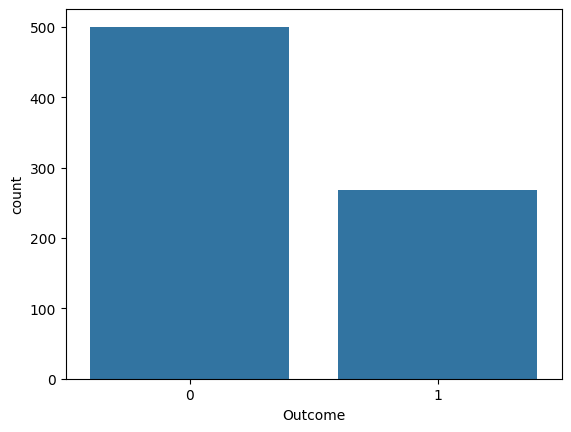

In [ ]:
print(data["Outcome"].value_counts())

sns.countplot(x="Outcome", data=data)
plt.show()

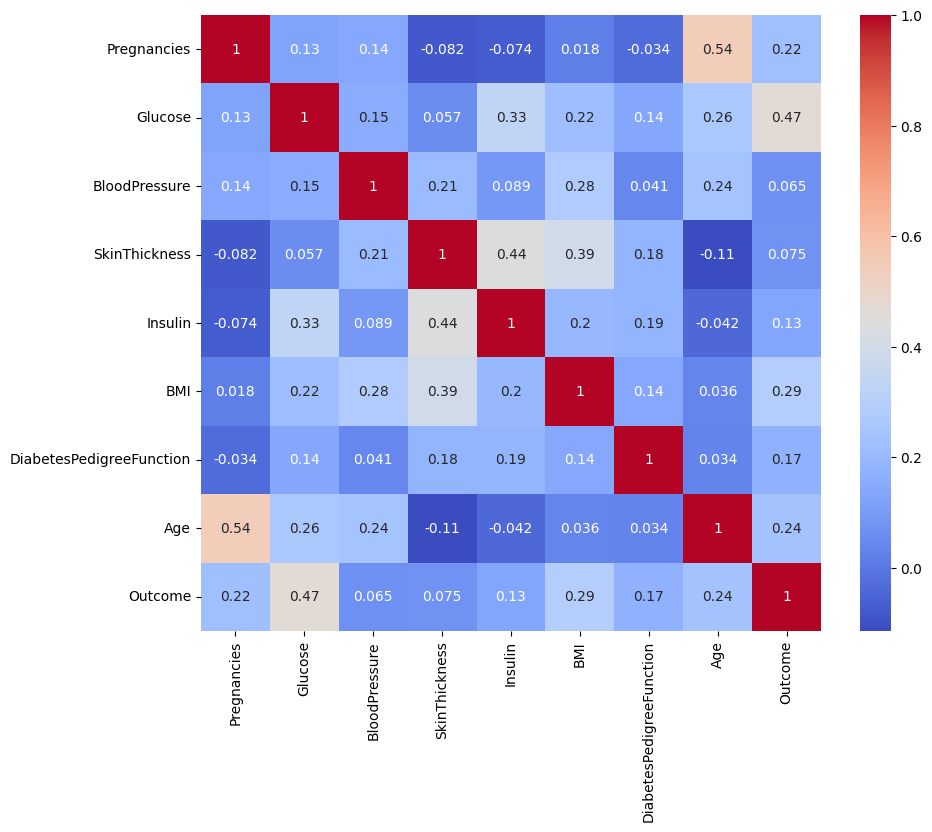

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
X = data.drop("Outcome", axis=1)

y = data["Outcome"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()  #creates an empty neural network model

# Input Layer + Hidden Layer 1
model.add(Dense(16,  #It is a hyperparameter chosen by the developer.
                activation="relu",
                input_shape=(8,)))  #input feature

# Hidden Layer 2
model.add(Dense(8,
                activation="relu"))

# Output Layer
model.add(Dense(1,
                activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,   #The model learns from the entire dataset 50 times
    batch_size=32,
    validation_split=0.2  #Validation data is used to check how well the model performs on unseen data during training
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6375 - loss: 0.6840 - val_accuracy: 0.6016 - val_loss: 0.6900
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6558 - loss: 0.6487 - val_accuracy: 0.5935 - val_loss: 0.6645
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6640 - loss: 0.6215 - val_accuracy: 0.5772 - val_loss: 0.6450
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6680 - loss: 0.5986 - val_accuracy: 0.5772 - val_loss: 0.6265
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6762 - loss: 0.5810 - val_accuracy: 0.6016 - val_loss: 0.6103
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6925 - loss: 0.5662 - val_accuracy: 0.6423 - val_loss: 0.5952
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7108 - loss: 0.5527 - val_accuracy: 0.6585 - val_loss: 0.5809
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7169 - loss: 0.5403 - val_accuracy: 0.6911 - val_loss

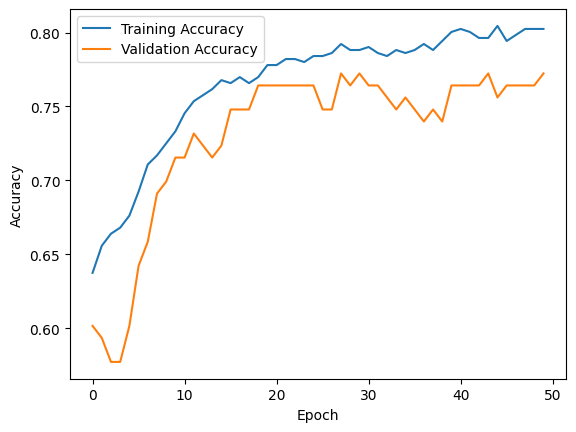

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

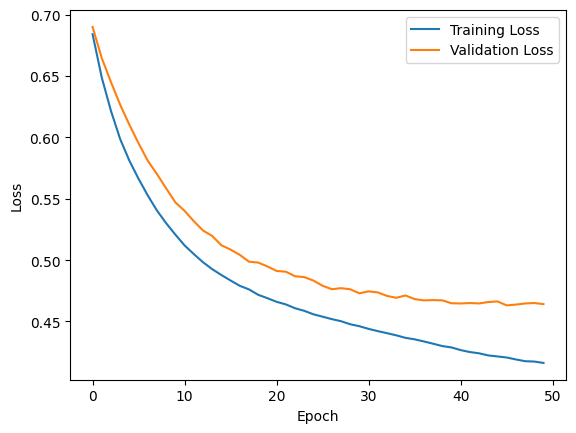

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7662337662337663


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[81 18]
 [18 37]]


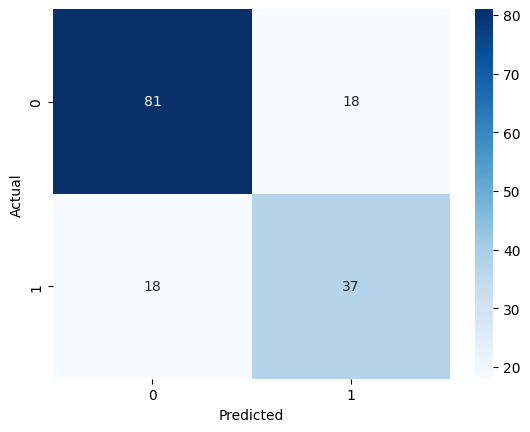

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [ ]:
new_patient = [[2,120,70,25,90,30.5,0.45,35]]

new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

if prediction > 0.5:
    print("Diabetes")
else:
    print("No Diabetes")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
No Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
Import Libraries
        │
        ▼
Load Dataset
        │
        ▼
Explore Dataset
        │
        ▼
Check Missing Values
        │
        ▼
Check Duplicate Values
        │
        ▼
Correlation Analysis
        │
        ▼
Separate Features (X) and Target (y)
        │
        ▼
Train-Test Split
        │
        ▼
Feature Scaling
        │
        ▼
Build ANN Model
        │
        ▼
Compile Model
        │
        ▼
Train Model
        │
        ▼
Plot Accuracy & Loss
        │
        ▼
Make Predictions
        │
        ▼
Evaluate Model
(Accuracy, Confusion Matrix, Classification Report)
        │
        ▼
Predict New Data
        │
        ▼
Save Model & Scaler

SyntaxError: invalid character '│' (U+2502) (4033179259.py, line 2)